## Effect of LDPC Decoding Iterations on PDSCH BLER

This notebook evaluates how the number of LDPC decoding iterations, controlled by `numIter`, affects the block error rate (BLER) of a 5G NR PDSCH link-level simulation.

For each value of `numIter`, the simulation runs an end-to-end PDSCH transmission over a CDL channel across a range of SNR values. The resulting BLER curves are then compared to show the trade-off between decoding performance and computational complexity.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

from neoradium import BandwidthPart, PDSCH, CdlChannel, AntennaPanel, random, SnrScheduler


In [2]:
numSlots = 200
snrScheduler = SnrScheduler(-12, 0.1, fastStep=1)   # Start at -12 dB, use increments of 0.1 dB

bwp = BandwidthPart(numRbs=24, spacing=30)          # Create the BandwidthPart object

# Create a PDSCH object
pdsch = PDSCH(bwp, numLayers=2, modulation="16QAM")
pdsch.setDMRS(additionalPos=1)

# Create an LDPC codec
ldpc = pdsch.getLdpcCodec(coderates=490/1024)

results = {}
for numIter in [3, 5, 10, 20]:
    results[numIter] = {}
    ldpc.cwCodecs[0].numIter = numIter
    print(f"\nSimulating end-to-end with numIter = {numIter}")
    print("SNR(dB)    Total Blocks  Block Errors  BLER(%)  Time(Sec.)")
    print("---------  ------------  ------------  -------  ----------")
    snrScheduler.reset()
    for snrDb in snrScheduler:
        random.setSeed(123)                             # Make the results reproducible for each SNR
        t0 = time.monotonic()                           # Start time for each SNR
        bwp.slotNo = 0

        # Create a CdlChannel object
        channel = CdlChannel(bwp, 'C', delaySpread=300, carrierFreq=4e9, dopplerShift=5,
                             txAntenna = AntennaPanel([2,4], polarization="x"), # 16 TX antenna elements
                             rxAntenna = AntennaPanel([1,2], polarization="x")) # 4 RX antenna elements

        blockErrors = 0
        totalBlocks = 0
        for slotNo in range(numSlots):
            pdsch.initGrid()                                                    # Create and initialize the PDSCH grid
            txBlock = random.bits(ldpc.txBlockSizes[0])                         # Random transport block
            numBits = pdsch.getBitCapacity()                                    # Bit capacity of the PDSCH grid

            rateMatchedCodeBlocks = ldpc.encode(txBlock, numBits[0])            # LDPC rate-matching and encoding
            pdsch.setPdschData(rateMatchedCodeBlocks)                           # Map/modulate encoded code blocks

            channelMatrix = channel.getChannelMatrix()                          # Get the channel matrix
            precoder = pdsch.getPrecodingMatrix(channelMatrix)                  # Precoder matrix

            txGrid = bwp.createGrid(len(channel.txAntenna))                     # Create a transmitted grid
            pdsch.precodeTo(txGrid, precoder)                                   # Precode data into txGrid
            
            rxGrid = txGrid.applyChannel(channelMatrix)                         # Apply the channel
            rxGrid = rxGrid.addNoise(snrDb=snrDb)                               # Add noise
                
            estChannelMatrix = channel.getEffChannel(channelMatrix, precoder)   # Get effective channel
                                                                      
            eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMatrix)        # Equalization
            llrs = pdsch.getLLRs(eqGrid, llrScales)                             # Demodulation (to LLRs)
            decodedTxBlock, crcMatch = ldpc.decode(llrs)                        # LDPC rate-recovery and decoding
            blockErrors += 0 if crcMatch[0][0] else 1                           # Update transport block errors
            totalBlocks += 1                                                    # Update number of transport blocks
            bler = blockErrors*100/totalBlocks                                  # BLER in percent

            print(f"\r{snrDb:^9.1f}  {totalBlocks:^12d}  {blockErrors:^12d}  " 
                  f"{bler:^7.2f}  {time.monotonic()-t0:^10.3f}", end='')
            channel.goNext()

        snrScheduler.setData(bler)
        print("")
    results[numIter] = snrScheduler.getSnrsAndData()


Simulating end-to-end with numIter = 3
SNR(dB)    Total Blocks  Block Errors  BLER(%)  Time(Sec.)
---------  ------------  ------------  -------  ----------
  -12.0        200           200       100.00     47.749  
  -11.0        200           200       100.00     48.129  
  -10.0        200           152        76.00     48.385  
  -10.1        200           171        85.50     47.930  
  -10.2        200           177        88.50     50.028  
  -10.3        200           185        92.50     49.731  
  -10.4        200           190        95.00     48.801  
  -10.5        200           199        99.50     48.800  
  -10.6        200           200       100.00     49.082  
  -10.7        200           200       100.00     48.801  
  -9.9         200           126        63.00     49.032  
  -9.8         200           112        56.00     48.697  
  -9.7         200            89        44.50     49.137  
  -9.6         200            69        34.50     48.395  
  -9.5         2

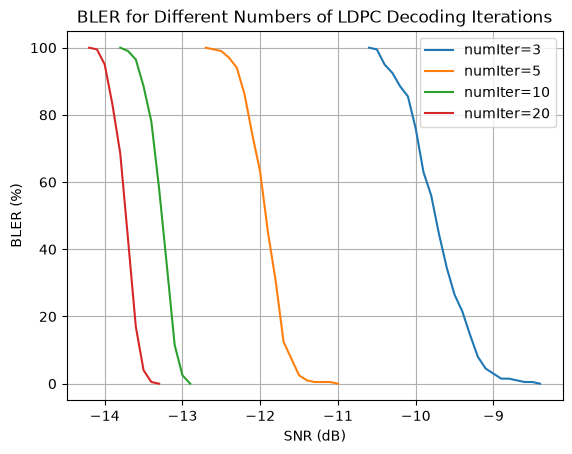

In [3]:
# Compare the results in a plot
for i,numIter in enumerate([3, 5, 10, 20]):
    plt.plot(results[numIter][0], results[numIter][1], label=f"numIter={numIter}")
plt.legend()
plt.title("BLER for Different Numbers of LDPC Decoding Iterations")
plt.grid()
plt.xlabel("SNR (dB)")
plt.ylabel("BLER (%)")
plt.show()